In [4]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.io import wavfile
from scipy.signal import stft, istft

# 1. Cargar el archivo de audio (Asegúrate de que 'Prueba.wav' esté en tu carpeta)
samplerate, data = wavfile.read('Prueba.wav')

# Convertir a canal mono si es estéreo (tomamos solo la primera columna)
if len(data.shape) > 1:
    data = data[:, 0]

# Normalizar los valores entre -1 y 1 para evitar desbordamientos matemáticos
data_norm = data / np.max(np.abs(data))

# Vector de tiempo general (para referencias)
t = np.arange(0, len(data_norm)) / samplerate

print(f"Audio cargado exitosamente. Frecuencia de muestreo: {samplerate} Hz")
print(f"Duración total: {len(data_norm)/samplerate:.2f} segundos")

Audio cargado exitosamente. Frecuencia de muestreo: 48000 Hz
Duración total: 12.48 segundos


In [6]:
print("Iniciando procesamiento matemático...")

# ==========================================
# PASO 1: APLICAR FFT POR VENTANAS (STFT)
# ==========================================
# nperseg=1024 define el tamaño de la ventana de tiempo a analizar
f, time_stft, Zxx = stft(data_norm, fs=samplerate, nperseg=1024)

# Zxx es la matriz compleja. Extraemos la Magnitud (volumen) y Fase (tiempo/retraso)
magnitud = np.abs(Zxx)
fase = np.angle(Zxx)

# ==========================================
# PASO 2: ESTIMACIÓN DEL PERFIL DE RUIDO
# ==========================================
# Tomamos el primer medio segundo (0.5s) asumiendo que ahí solo hay ruido de fondo
tiempo_ruido_segundos = 0.5 
muestras_ruido = int(tiempo_ruido_segundos / (time_stft[1] - time_stft[0]))

# Calculamos el promedio del ruido para cada frecuencia en ese lapso de tiempo
perfil_ruido = np.mean(magnitud[:, :muestras_ruido], axis=1, keepdims=True)

# ==========================================
# PASO 3: SUSTRACCIÓN ESPECTRAL VECTORIAL
# ==========================================
# Restamos la matriz de ruido a la matriz del audio completo
# factor_reduccion: Ajusta este valor (ej. 1.0 a 3.0) si quieres borrar más o menos ruido
factor_reduccion = 1.5 
magnitud_limpia = magnitud - (perfil_ruido * factor_reduccion)

# Los volúmenes no pueden ser negativos, por lo que igualamos a 0 los que bajaron de cero
magnitud_limpia[magnitud_limpia < 0] = 0

# ==========================================
# PASO 4: RECONSTRUCCIÓN (ISTFT)
# ==========================================
# Volvemos a unir la magnitud procesada con la fase original usando notación compleja (1j)
Zxx_limpio = magnitud_limpia * np.exp(1j * fase)

# Aplicamos la Transformada Inversa para regresar de las frecuencias al tiempo
_, audio_recuperado = istft(Zxx_limpio, fs=samplerate)

# ==========================================
# PASO 5: EXPORTACIÓN
# ==========================================
# Volvemos a escalar al formato de 16 bits
audio_final = np.int16(audio_recuperado * 32767 / np.max(np.abs(audio_recuperado)))
wavfile.write('Prueba_Sustraccion_Manual.wav', samplerate, audio_final)

print("¡Procesamiento exitoso! Se ha generado el archivo 'Prueba_Sustraccion_Manual.wav'")

Iniciando procesamiento matemático...
¡Procesamiento exitoso! Se ha generado el archivo 'Prueba_Sustraccion_Manual.wav'


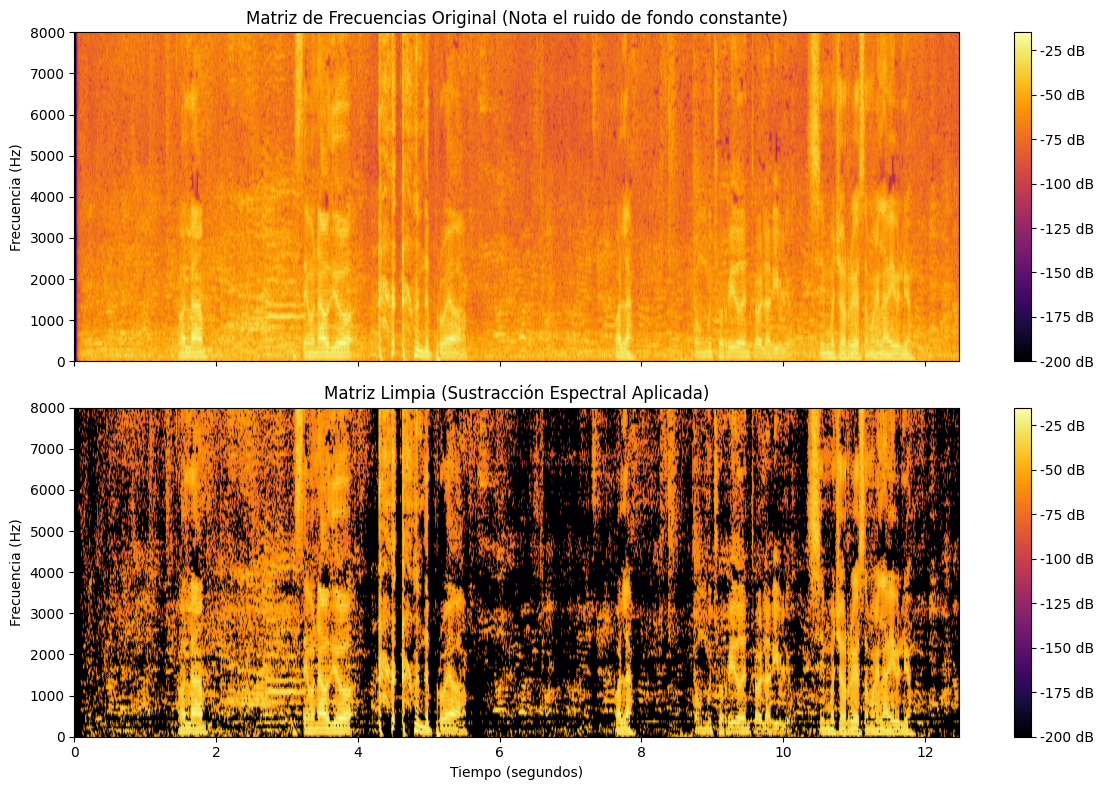

In [7]:
# ==========================================
# GRAFICACIÓN DE ESPECTROGRAMAS (ANTES Y DESPUÉS)
# ==========================================
fig, axs = plt.subplots(2, 1, figsize=(12, 8), sharex=True, sharey=True)

# Utilizamos escala logarítmica (dB) para visualizar mejor la energía acústica
Zxx_db = 20 * np.log10(np.abs(Zxx) + 1e-10)
Zxx_limpio_db = 20 * np.log10(np.abs(Zxx_limpio) + 1e-10)

# Gráfico 1: Audio Original
img1 = axs[0].pcolormesh(time_stft, f, Zxx_db, shading='gouraud', cmap='inferno')
axs[0].set_title('Matriz de Frecuencias Original (Nota el ruido de fondo constante)')
axs[0].set_ylabel('Frecuencia (Hz)')
fig.colorbar(img1, ax=axs[0], format='%+2.0f dB')

# Gráfico 2: Audio Procesado
img2 = axs[1].pcolormesh(time_stft, f, Zxx_limpio_db, shading='gouraud', cmap='inferno')
axs[1].set_title('Matriz Limpia (Sustracción Espectral Aplicada)')
axs[1].set_xlabel('Tiempo (segundos)')
axs[1].set_ylabel('Frecuencia (Hz)')
fig.colorbar(img2, ax=axs[1], format='%+2.0f dB')

# Limitamos la vista a las frecuencias de la voz (0 a 8000 Hz)
axs[0].set_ylim(0, 8000)
axs[1].set_ylim(0, 8000)

plt.tight_layout()
plt.show()